In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Load the Adult Income dataset

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

df = pd.read_csv(
    url,
    names=columns,
    skipinitialspace=True
)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Dataset shape: (32561, 15)

First 5 rows:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
print("Dataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["income"].value_counts())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None

Missing values:
age               0
workclass         0
fnlwgt    

In [ ]:
# Convert target variable to binary

df["income"] = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

print("Target converted successfully!")
print(df["income"].value_counts())

Target converted successfully!
income
0    24720
1     7841
Name: count, dtype: int64


In [ ]:
# Separate features and target
X = df.drop("income", axis=1)
y = df["income"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Features shape: (32561, 14)
Target shape: (32561,)

Target distribution:
income
0    24720
1     7841
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (26048, 14)
Testing data: (6513, 14)


In [ ]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

Categorical features:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical preprocessing
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

print("Numerical and categorical preprocessing pipelines created!")

Numerical and categorical preprocessing pipelines created!


In [ ]:
# Combine both preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("ColumnTransformer created successfully!")

ColumnTransformer created successfully!


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

print("Four models created successfully!")

for name in models:
    print("-", name)

Four models created successfully!
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting


In [ ]:
from sklearn.model_selection import StratifiedKFold

# Create a reusable pipeline for each model
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

print("Model pipelines created successfully!")

for name in pipelines:
    print("-", name)

Model pipelines created successfully!
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting


In [ ]:
# Stratified K-Fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold Stratified Cross-Validation created successfully!")

5-fold Stratified Cross-Validation created successfully!


In [ ]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grids
param_grids = {
    "Logistic Regression": {
        "classifier__C": [0.1, 1, 10]
    },

    "Decision Tree": {
        "classifier__max_depth": [5, 10, 20, None],
        "classifier__min_samples_split": [2, 5, 10]
    },

    "Random Forest": {
        "classifier__n_estimators": [100, 200],
        "classifier__max_depth": [None, 10, 20],
        "classifier__min_samples_split": [2, 5]
    },

    "Gradient Boosting": {
        "classifier__n_estimators": [100, 200],
        "classifier__learning_rate": [0.05, 0.1],
        "classifier__max_depth": [3, 5]
    }
}

print("Hyperparameter grids created successfully!")

Hyperparameter grids created successfully!


In [ ]:
# Perform GridSearchCV for all four models

grid_searches = {}
best_models = {}

for name in pipelines:
    print(f"\nTuning {name}...")

    grid = GridSearchCV(
        estimator=pipelines[name],
        param_grid=param_grids[name],
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    grid_searches[name] = grid
    best_models[name] = grid.best_estimator_

    print("Best parameters:", grid.best_params_)
    print("Best CV ROC-AUC:", round(grid.best_score_, 4))

print("\nAll models tuned successfully!")


Tuning Logistic Regression...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best parameters: {'classifier__C': 1}
Best CV ROC-AUC: 0.9059

Tuning Decision Tree...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 10}
Best CV ROC-AUC: 0.8952

Tuning Random Forest...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'classifier__max_depth': 20, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV ROC-AUC: 0.9158

Tuning Gradient Boosting...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 200}
Best CV ROC-AUC: 0.9281

All models tuned successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, model in best_models.items():
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)

print("Model Comparison:")
display(results_df.round(4))

Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8560,0.7397,0.6199,0.6745,0.9098
1,Decision Tree,0.8566,0.7168,0.6684,0.6917,0.9056
2,Random Forest,0.8690,0.7923,0.6180,0.6944,0.9205
3,Gradient Boosting,0.8769,0.7850,0.6728,0.7246,0.9312


In [18]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

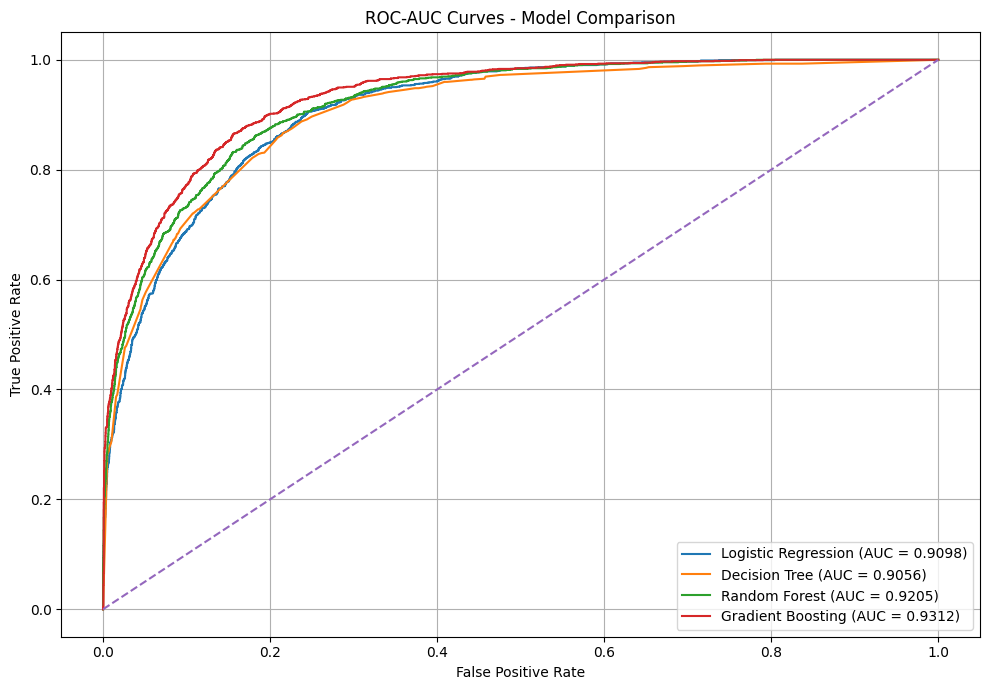

ROC-AUC curves generated successfully!


In [19]:
# Step 10: ROC-AUC Curves for all tuned models

plt.figure(figsize=(10, 7))

for name, model in best_models.items():

    # Get prediction probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Calculate AUC
    auc_score = roc_auc_score(y_test, y_prob)

    # Plot
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.4f})"
    )

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curves - Model Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("ROC-AUC curves generated successfully!")

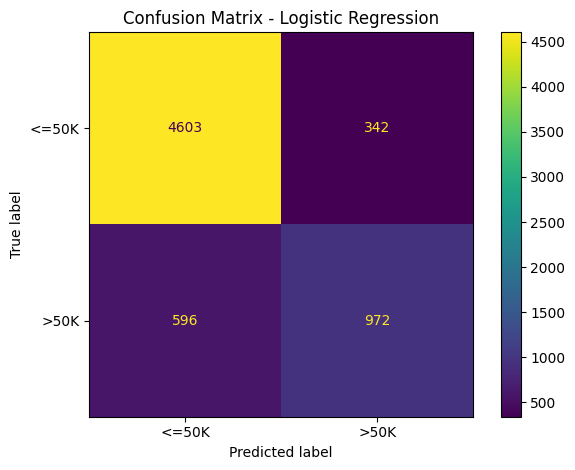

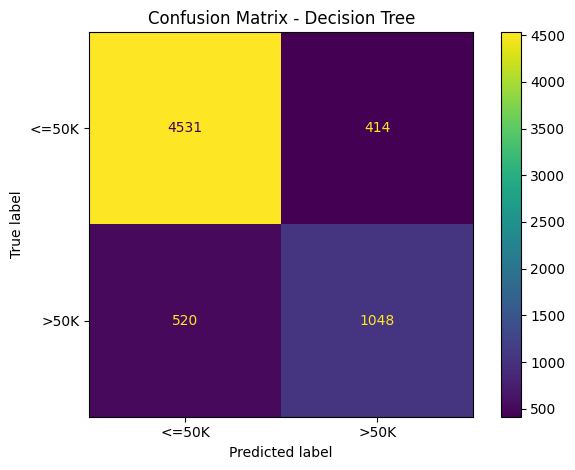

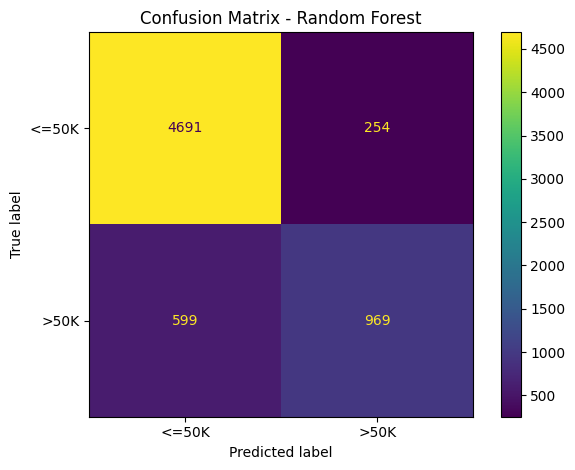

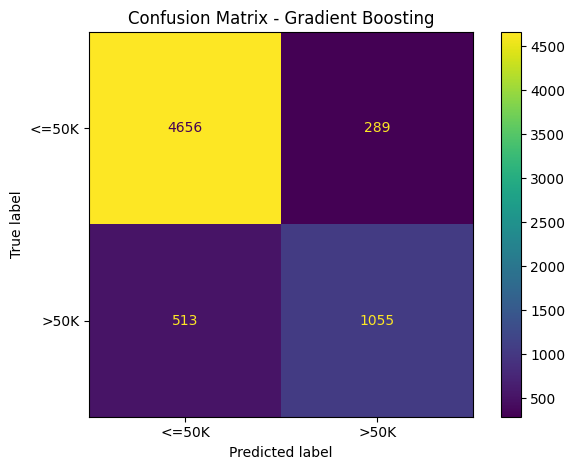

Confusion matrices generated successfully!


In [20]:
# Step 11: Confusion Matrix for all tuned models

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in best_models.items():

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Display confusion matrix
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["<=50K", ">50K"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

print("Confusion matrices generated successfully!")

In [21]:
# Step 12: Save all tuned models

import joblib
import os

os.makedirs("saved_models", exist_ok=True)

for name, model in best_models.items():
    filename = name.lower().replace(" ", "_") + "_tuned.pkl"
    filepath = os.path.join("saved_models", filename)

    joblib.dump(model, filepath)

    print(f"{name} saved successfully -> {filepath}")

print("\nAll tuned models saved successfully!")

Logistic Regression saved successfully -> saved_models/logistic_regression_tuned.pkl
Decision Tree saved successfully -> saved_models/decision_tree_tuned.pkl
Random Forest saved successfully -> saved_models/random_forest_tuned.pkl
Gradient Boosting saved successfully -> saved_models/gradient_boosting_tuned.pkl

All tuned models saved successfully!


In [22]:
# Step 13: Select the champion model based on ROC-AUC

best_model_name = results_df.loc[
    results_df["ROC-AUC"].idxmax(), "Model"
]

best_model_score = results_df["ROC-AUC"].max()

champion_model = best_models[best_model_name]

print("Champion Model:")
print(f"Model   : {best_model_name}")
print(f"ROC-AUC : {best_model_score:.4f}")

Champion Model:
Model   : Gradient Boosting
ROC-AUC : 0.9312


In [23]:
# Save champion model

joblib.dump(
    champion_model,
    "champion_model.pkl"
)

print("Champion model saved successfully!")

Champion model saved successfully!


In [24]:
# Step 14: Final model comparison summary

final_results = results_df.copy()

# Round metrics for presentation
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

final_results[metric_columns] = final_results[metric_columns].round(4)

print("FINAL MODEL COMPARISON")
print("=" * 70)
display(final_results)

# Save comparison table
final_results.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("\nModel comparison saved successfully!")

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8560,0.7397,0.6199,0.6745,0.9098
1,Decision Tree,0.8566,0.7168,0.6684,0.6917,0.9056
2,Random Forest,0.8690,0.7923,0.6180,0.6944,0.9205
3,Gradient Boosting,0.8769,0.7850,0.6728,0.7246,0.9312



Model comparison saved successfully!


In [25]:
# Verify saved deliverables

import os

print("Saved deliverables:")
for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith((".pkl", ".csv")):
            print(os.path.join(root, file))

Saved deliverables:
./model_comparison_results.csv
./champion_model.pkl
./saved_models/gradient_boosting_tuned.pkl
./saved_models/decision_tree_tuned.pkl
./saved_models/logistic_regression_tuned.pkl
./saved_models/random_forest_tuned.pkl
./sample_data/mnist_train_small.csv
./sample_data/california_housing_test.csv
./sample_data/mnist_test.csv
./sample_data/california_housing_train.csv


# Conclusion

This project compared four supervised classification models for the Adult
Income classification problem:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting

Each model was combined with the preprocessing pipeline using Scikit-Learn's
Pipeline and evaluated using 5-fold Stratified Cross-Validation.

GridSearchCV was used for hyperparameter optimization, with ROC-AUC as the
cross-validation scoring metric.

The tuned models were evaluated on the held-out test set using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix

ROC-AUC curves were generated to compare the models, and the model with the
highest test-set ROC-AUC was selected as the champion model.

The tuned models and the selected champion model were serialized using
Joblib so that they can be reused without retraining.

## Limitations

The reported results depend on the selected dataset and train/test split.
Test-set performance should not be interpreted as guaranteed performance on
future or unseen populations.

Further validation on additional data would be appropriate before using a
model in a real-world decision-making system.